# 📄 Medical Report Generation with Mistral-7B
### Part 2 of 2 — LLM-Based Diagnostic Report Generation

**Author:** Maryam Rafaqat

---

## 📌 Overview
This notebook loads the **trained DenseNet121 models** from Part 1 and uses **Mistral-7B** to generate
full structured clinical reports from any breast cancer histopathology image.

### Files required (downloaded from the CNN Kaggle notebook output):
| File | Purpose |
|---|---|
| `binary_model.h5` | Binary benign/malignant classifier |
| `benign_subtype_model.h5` | 4-class benign subtype classifier |
| `malignant_subtype_model.h5` | 4-class malignant subtype classifier |
| `label_maps.json` | Class index ↔ name mappings |
| `cnn_predictions.json` | Pre-computed predictions for batch evaluation |

### How to run on Kaggle:
1. Upload the 3 `.h5` and 2 `.json` files as a new **Kaggle Dataset**
2. Add it via **Add Data** → set `MODELS_DIR` in Cell 2 to point to it
3. A GPU (T4/A100) is required for Mistral-7B

## 1. Install Dependencies

In [ ]:
!pip install -q --upgrade "scipy>=1.14.0" "seaborn>=0.13.2"

In [1]:
# !pip install -q --upgrade "scipy>=1.14.0"
# !pip install -q transformers accelerate bitsandbytes rouge-score bert-score sentencepiece tensorflow opencv-python-headless

import os, json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import tensorflow as tf
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow : {tf.__version__}')
print(f'PyTorch    : {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

2026-06-06 22:54:28.607016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780786468.634294     409 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780786468.643055     409 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780786468.674270     409 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780786468.674289     409 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780786468.674291     409 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
PyTorch    : 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration — Point to Your Saved Model Files

In [2]:
import os, json, cv2
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import load_model

# ── Set this to wherever you uploaded your CNN output files ────────────────
# Kaggle example: '/kaggle/input/breakhis-models'
MODELS_DIR = '/kaggle/input/datasets/maryamrafaqat/files-for-llms'   # <-- UPDATE THIS

IMG_SIZE = 224

BENIGN_SUBTYPES = {
    'adenosis': 0, 'fibroadenoma': 1,
    'phyllodes_tumor': 2, 'tubular_adenoma': 3,
}
MALIGNANT_SUBTYPES = {
    'ductal_carcinoma': 0, 'lobular_carcinoma': 1,
    'mucinous_carcinoma': 2, 'papillary_carcinoma': 3,
}
BENIGN_IDX_TO_NAME    = {v: k for k, v in BENIGN_SUBTYPES.items()}
MALIGNANT_IDX_TO_NAME = {v: k for k, v in MALIGNANT_SUBTYPES.items()}

def _p(filename):
    return str(Path(MODELS_DIR) / filename)

# ── Load the 3 Keras models ────────────────────────────────────────────────
print('Loading CNN models...')
binary_model    = load_model(_p('binary_model.h5'))
benign_model    = load_model(_p('benign_subtype_model.h5'))
malignant_model = load_model(_p('malignant_subtype_model.h5'))
print('  ✓ binary_model.h5')
print('  ✓ benign_subtype_model.h5')
print('  ✓ malignant_subtype_model.h5')

# ── Load label maps ────────────────────────────────────────────────────────
label_map_file = _p('label_maps.json')
if Path(label_map_file).exists():
    with open(label_map_file) as f:
        _lm = json.load(f)
    BENIGN_SUBTYPES    = _lm['benign_subtypes']
    MALIGNANT_SUBTYPES = _lm['malignant_subtypes']
    BENIGN_IDX_TO_NAME    = {int(v): k for k, v in BENIGN_SUBTYPES.items()}
    MALIGNANT_IDX_TO_NAME = {int(v): k for k, v in MALIGNANT_SUBTYPES.items()}
    print('  ✓ label_maps.json')

# ── Load pre-computed predictions ─────────────────────────────────────────
pred_file = _p('cnn_predictions.json')
if Path(pred_file).exists():
    with open(pred_file) as f:
        CNN_PREDICTIONS = json.load(f)
    print(f'  ✓ cnn_predictions.json  ({len(CNN_PREDICTIONS)} predictions)')
else:
    CNN_PREDICTIONS = []
    print('  ⚠ cnn_predictions.json not found.')

print('\nAll models loaded successfully.')

Loading CNN models...


I0000 00:00:1780786593.169901     409 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780786593.175061     409 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  ✓ binary_model.h5
  ✓ benign_subtype_model.h5
  ✓ malignant_subtype_model.h5
  ✓ label_maps.json
  ✓ cnn_predictions.json  (8 predictions)

All models loaded successfully.


## 3. CNN Inference — Predict on Any New Image

I0000 00:00:1780786754.985906     474 service.cc:152] XLA service 0x7cb06800b020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780786754.985941     474 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780786754.985945     474 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780786756.642466     474 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780786763.789091     474 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Prediction result:
{
  "binary": {
    "prediction": "benign",
    "confidence": 0.9993,
    "probabilities": {
      "benign": 0.9993,
      "malignant": 0.0007
    }
  },
  "subtype": {
    "prediction": "adenosis",
    "confidence": 0.9939,
    "uncertainty": "low",
    "differential": {
      "adenosis": 0.9939,
      "phyllodes_tumor": 0.0026,
      "fibroadenoma": 0.002,
      "tubular_adenoma": 0.0015
    }
  },
  "display_label": "Benign: Adenosis",
  "image_path": "/kaggle/input/datasets/maryamrafaqat/test-data/test/adenosis/SOB_B_A-14-22549AB-400-020.png"
}


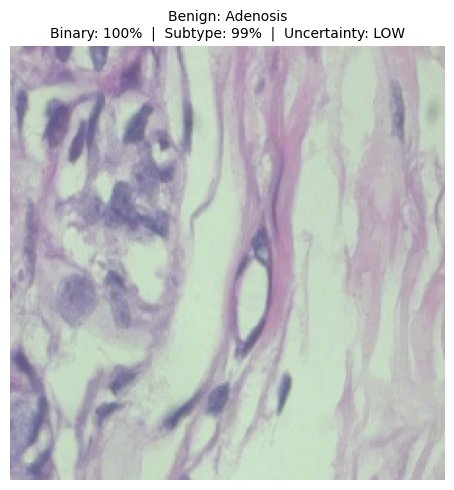

In [3]:
def apply_clahe(img_bgr: np.ndarray) -> np.ndarray:
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def load_and_preprocess(img_path: str) -> np.ndarray:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f'Cannot read image: {img_path}')
    img = apply_clahe(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img / 255.0

def _uncertainty_level(probs: np.ndarray) -> str:
    top1_margin = np.max(probs) - np.sort(probs)[-2]
    if top1_margin >= 0.40: return 'low'
    if top1_margin >= 0.20: return 'moderate'
    return 'high'

def predict_image(img_path: str) -> dict:
    """Full two-stage DenseNet121 pipeline → returns rich structured dict for Mistral."""
    img_batch = np.expand_dims(load_and_preprocess(img_path), 0)

    # Stage 1: Binary
    mal_prob    = float(binary_model.predict(img_batch, verbose=0)[0][0])
    ben_prob    = round(1.0 - mal_prob, 4)
    mal_prob    = round(mal_prob, 4)
    binary_pred = 'malignant' if mal_prob > 0.5 else 'benign'
    binary_conf = mal_prob if binary_pred == 'malignant' else ben_prob

    # Stage 2: Subtype
    if binary_pred == 'benign':
        raw = benign_model.predict(img_batch, verbose=0)[0]
        idx_to_name = BENIGN_IDX_TO_NAME
    else:
        raw = malignant_model.predict(img_batch, verbose=0)[0]
        idx_to_name = MALIGNANT_IDX_TO_NAME

    top_idx      = int(np.argmax(raw))
    subtype_name = idx_to_name[top_idx]
    subtype_conf = round(float(raw[top_idx]), 4)
    differential = {
        idx_to_name[i]: round(float(p), 4)
        for i, p in sorted(enumerate(raw), key=lambda x: -x[1])
    }

    return {
        'binary' : {
            'prediction'   : binary_pred,
            'confidence'   : round(binary_conf, 4),
            'probabilities': {'benign': ben_prob, 'malignant': mal_prob},
        },
        'subtype': {
            'prediction' : subtype_name,
            'confidence' : subtype_conf,
            'uncertainty': _uncertainty_level(raw),
            'differential': differential,
        },
        'display_label': f"{binary_pred.capitalize()}: {subtype_name.replace('_',' ').title()}",
        'image_path'   : img_path,
    }

# ── TEST ON A NEW IMAGE ────────────────────────────────────────────────────
# Change this path to any .png histopathology image on your machine / Kaggle
TEST_IMAGE_PATH = '/kaggle/input/datasets/maryamrafaqat/test-data/test/adenosis/SOB_B_A-14-22549AB-400-020.png'   # <-- UPDATE THIS

if Path(TEST_IMAGE_PATH).exists():
    result = predict_image(TEST_IMAGE_PATH)
    print('Prediction result:')
    print(json.dumps(result, indent=2))

    # Show the image
    img_display = cv2.cvtColor(cv2.imread(TEST_IMAGE_PATH), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.resize(img_display, (IMG_SIZE, IMG_SIZE)))
    plt.title(f"{result['display_label']}\n"
              f"Binary: {result['binary']['confidence']:.0%}  |  "
              f"Subtype: {result['subtype']['confidence']:.0%}  |  "
              f"Uncertainty: {result['subtype']['uncertainty'].upper()}", fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'Test image not found at: {TEST_IMAGE_PATH}')
    print('Update TEST_IMAGE_PATH above and re-run this cell.')
    print('\nCNN predictions from cnn_predictions.json will be used for report generation.')

## 4. Load Mistral-7B with 4-bit Quantization

In [4]:
MODEL_ID = 'mistralai/Mistral-7B-Instruct-v0.2'

# 4-bit quantization for GPU efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16
)

print(f'Loading tokenizer from {MODEL_ID}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print('Loading model with 4-bit quantization...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True
)

print('✅ Mistral-7B loaded successfully.')

Loading tokenizer from mistralai/Mistral-7B-Instruct-v0.2...
Loading model with 4-bit quantization...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ Mistral-7B loaded successfully.


## 5. Prompt Engineering

In [5]:
SYSTEM_PROMPT = """You are a compassionate, expert AI cancer advisor. A patient has just received \
an AI-assisted breast cancer classification from a histopathology image. Your job is to explain the \
result to them in clear, caring, and informative language — like a knowledgeable friend who is also \
a medical expert.

Generate a detailed patient report with EXACTLY these 7 sections using these headings:

1. WHAT WE FOUND
   Explain the diagnosis (benign or malignant, and the specific subtype) in simple, plain language. \
   Describe what this type of tissue change means in the breast.

2. IS THIS DANGEROUS?
   Give an honest, calibrated answer. Rate danger level as: LOW / MODERATE / HIGH. \
   Explain what that means for this specific cancer/condition type, including survival rates or \
   prognosis if relevant.

3. DO YOU NEED TO SEE A DOCTOR?
   Give a clear urgency level: ROUTINE / SOON (within weeks) / URGENT (within days). \
   Explain what kind of specialist they should see and why.

4. WHAT TREATMENT MIGHT BE NEEDED?
   Explain the typical treatment pathway for this specific subtype. Cover surgery, \
   chemotherapy, radiation, hormone therapy, targeted therapy — state clearly which are \
   typically needed, which are sometimes needed, and which are usually NOT needed.

5. IS CHEMOTHERAPY NECESSARY?
   Answer this directly and specifically for this subtype. Explain what factors determine \
   whether chemo is needed (e.g. receptor status, tumour grade, stage).

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
   List specific red-flag symptoms that mean the patient must go to a doctor or emergency \
   room immediately, tailored to this cancer type.

7. IMPORTANT DISCLAIMER
   Remind the patient clearly but kindly that this is an AI tool, not a replacement for \
   a qualified pathologist or oncologist, and that all decisions must be confirmed by a \
   medical professional.

Rules:
- Use plain language. Avoid unexplained medical jargon.
- Be honest but compassionate — do not be falsely reassuring or unnecessarily alarming.
- Keep each section focused and practical.
- For BENIGN findings, still take them seriously but reassure appropriately.
- Always mention that the AI confidence score and uncertainty level affect how much \
  weight to place on this result."""


_UNCERTAINTY_NOTE = {
    'low'     : 'The AI model is highly confident in this result.',
    'moderate': 'The AI model has moderate confidence — a pathologist review is especially important.',
    'high'    : 'WARNING: The AI model has LOW confidence in this result. Professional pathologist review is essential before drawing any conclusions.',
}

def build_prompt(pred: dict) -> str:
    b = pred['binary']
    s = pred['subtype']

    subtype_display = s['prediction'].replace('_', ' ').title()
    binary_display  = b['prediction'].capitalize()

    # Ranked subtype differential table
    diff_lines = '\n'.join(
        f"    {rank+1}. {name.replace('_',' ').title():<30} {prob*100:.1f}%"
        for rank, (name, prob) in enumerate(s['differential'].items())
    )

    uncertainty_note = _UNCERTAINTY_NOTE[s['uncertainty']]

    user_msg = (
        f"PATIENT AI CANCER SCREENING RESULT\n"
        f"{'─'*55}\n\n"
        f"IMAGE ANALYSIS RESULT:\n"
        f"  • Overall classification : {binary_display.upper()}\n"
        f"  • Specific subtype       : {subtype_display}\n"
        f"  • Binary confidence      : {b['confidence']*100:.1f}%  "
        f"(Malignant probability: {b['probabilities']['malignant']*100:.1f}%, "
        f"Benign probability: {b['probabilities']['benign']*100:.1f}%)\n"
        f"  • Subtype confidence     : {s['confidence']*100:.1f}%\n"
        f"  • AI uncertainty level   : {s['uncertainty'].upper()}\n"
        f"  • Confidence note        : {uncertainty_note}\n\n"
        f"SUBTYPE PROBABILITY BREAKDOWN (all considered subtypes):\n"
        f"{diff_lines}\n\n"
        f"Please generate the full patient advisory report for this finding."
    )

    return f"[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST]"

# Preview prompt for the first prediction
if CNN_PREDICTIONS:
    print('SAMPLE PROMPT PREVIEW:')
    print('=' * 70)
    print(build_prompt(CNN_PREDICTIONS[0]))

SAMPLE PROMPT PREVIEW:
[INST] You are a compassionate, expert AI cancer advisor. A patient has just received an AI-assisted breast cancer classification from a histopathology image. Your job is to explain the result to them in clear, caring, and informative language — like a knowledgeable friend who is also a medical expert.

Generate a detailed patient report with EXACTLY these 7 sections using these headings:

1. WHAT WE FOUND
   Explain the diagnosis (benign or malignant, and the specific subtype) in simple, plain language.    Describe what this type of tissue change means in the breast.

2. IS THIS DANGEROUS?
   Give an honest, calibrated answer. Rate danger level as: LOW / MODERATE / HIGH.    Explain what that means for this specific cancer/condition type, including survival rates or    prognosis if relevant.

3. DO YOU NEED TO SEE A DOCTOR?
   Give a clear urgency level: ROUTINE / SOON (within weeks) / URGENT (within days).    Explain what kind of specialist they should see and w

## 6. Report Generation

In [6]:
def generate_report(pred: dict, max_new_tokens: int = 600) -> str:
    """Generate a medical report for one CNN prediction dict using Mistral-7B."""
    prompt = build_prompt(pred)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=1536)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,
            top_p=0.85,
            do_sample=True,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    n_input = inputs['input_ids'].shape[1]
    return tokenizer.decode(outputs[0][n_input:], skip_special_tokens=True).strip()


# ── Decide what predictions to generate reports for ───────────────────────
# Priority 1: if the user tested a new image above, generate its report first
# Priority 2: use the batch from cnn_predictions.json
if Path(TEST_IMAGE_PATH).exists():
    preds_to_report = [predict_image(TEST_IMAGE_PATH)] + CNN_PREDICTIONS
    print(f'Generating report for new image + {len(CNN_PREDICTIONS)} batch predictions...\n')
else:
    preds_to_report = CNN_PREDICTIONS
    print(f'Generating reports for {len(CNN_PREDICTIONS)} batch predictions from cnn_predictions.json...\n')

reports = []
for i, pred in enumerate(preds_to_report):
    label = pred['display_label']
    unc   = pred['subtype']['uncertainty']
    print(f'  [{i+1}/{len(preds_to_report)}] {label}  (uncertainty: {unc})')
    report_text = generate_report(pred)
    reports.append({
        'prediction'  : label,
        'binary_conf' : pred['binary']['confidence'],
        'subtype_conf': pred['subtype']['confidence'],
        'uncertainty' : unc,
        'differential': pred['subtype']['differential'],
        'report'      : report_text,
    })

print('\n✅ All reports generated.')

Generating report for new image + 8 batch predictions...

  [1/9] Benign: Adenosis  (uncertainty: low)
  [2/9] Malignant: Lobular Carcinoma  (uncertainty: low)
  [3/9] Malignant: Lobular Carcinoma  (uncertainty: low)
  [4/9] Malignant: Ductal Carcinoma  (uncertainty: low)
  [5/9] Malignant: Mucinous Carcinoma  (uncertainty: low)
  [6/9] Malignant: Lobular Carcinoma  (uncertainty: low)
  [7/9] Malignant: Ductal Carcinoma  (uncertainty: low)


KeyboardInterrupt: 

## 7. Ground Truth Reference Reports
These are clinical reference summaries sourced from pathology literature (WHO Classification of
Tumours, UpToDate, PathologyOutlines). Each is used as ground truth to score the LLM report.

In [ ]:
# Ground truth patient-advisory reference reports.
# Written in the same 7-section format the LLM is asked to produce.
# Sources: WHO Classification of Tumours (5th Ed.), ACS, NCI, NCCN Guidelines,
#          UpToDate, PathologyOutlines.com

REFERENCE_REPORTS = {

'Benign: Fibroadenoma': """
1. WHAT WE FOUND
Your breast tissue sample shows a fibroadenoma — a completely benign (non-cancerous) lump. \
A fibroadenoma is made up of both glandular tissue (the milk-producing parts of the breast) and \
fibrous connective tissue that have grown together in a well-contained, rounded lump. \
It is not cancer and it did not invade surrounding tissue.

2. IS THIS DANGEROUS?
DANGER LEVEL: LOW.
Fibroadenomas are not cancer and do not spread. The chance of a fibroadenoma turning into cancer \
is extremely small — less than 0.3%. Most women with fibroadenomas live completely normal lives \
with no health consequences from the lump itself. The overall outlook is excellent.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: ROUTINE.
You should see a breast specialist or your GP within the next few months for confirmation. \
Although the result is benign, the diagnosis should be confirmed with imaging (ultrasound) and \
ideally a core needle biopsy to be absolutely sure. There is no emergency.

4. WHAT TREATMENT MIGHT BE NEEDED?
Usually no treatment is needed. Most fibroadenomas are simply monitored with ultrasound every \
6–12 months. Surgery (removal) is considered only if: the lump is growing rapidly, it is larger \
than 3 cm, it is causing pain or anxiety, or the biopsy result is uncertain. \
No chemotherapy, radiation, or hormone therapy is needed.

5. IS CHEMOTHERAPY NECESSARY?
No. Chemotherapy is a cancer treatment and fibroadenoma is not cancer. \
Chemotherapy is not needed, recommended, or appropriate for this condition.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
See a doctor promptly if you notice: rapid increase in lump size over a few weeks, \
skin changes over the lump (redness, dimpling, puckering), nipple discharge (especially bloody), \
the lump becomes painful, hard, or fixed to the skin, or you find new lumps elsewhere in the breast.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and discussed with a breast specialist before any clinical decisions are made. \
AI results can have errors — your doctor's assessment always takes priority.
""",

'Malignant: Ductal Carcinoma': """
1. WHAT WE FOUND
Your breast tissue sample shows Invasive Ductal Carcinoma (IDC) — the most common type of \
breast cancer, accounting for about 70–80% of all breast cancer cases. "Ductal" means it \
started in the milk ducts of the breast. "Invasive" means the cancer cells have grown beyond \
the duct walls into surrounding breast tissue. This is a true breast cancer that requires \
medical treatment.

2. IS THIS DANGEROUS?
DANGER LEVEL: HIGH — but highly treatable, especially when caught early.
IDC is a serious diagnosis. However, breast cancer treatment has advanced enormously — \
the 5-year survival rate for localised IDC (not spread to other organs) is over 99%. \
Even when spread to nearby lymph nodes, survival rates remain around 86%. \
The danger level depends heavily on the stage, tumour grade, and hormone receptor status, \
which your doctor will determine.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: URGENT — please book an appointment within the next few days.
You need to be seen by a breast cancer specialist (breast surgeon + oncologist) as soon as \
possible. The sooner treatment begins, the better the outcomes. Do not wait.

4. WHAT TREATMENT MIGHT BE NEEDED?
Treatment typically involves a combination of:
- Surgery: Either lumpectomy (remove just the tumour) or mastectomy (remove the breast), \
  depending on tumour size and spread.
- Radiation therapy: Usually recommended after lumpectomy to destroy any remaining cancer cells.
- Chemotherapy: Sometimes needed — depends on tumour grade, size, and receptor status (see below).
- Hormone therapy (e.g. Tamoxifen, Letrozole): Needed if the cancer is oestrogen/progesterone \
  receptor positive (ER+/PR+), which is the case in about 80% of IDC patients.
- Targeted therapy (e.g. Herceptin/Trastuzumab): Needed if the cancer is HER2-positive (~15–20% \
  of IDC cases).

5. IS CHEMOTHERAPY NECESSARY?
It depends on several factors your oncologist will test:
- If the cancer is hormone receptor positive (ER+) and HER2 negative, a genomic test (Oncotype DX) \
  may show chemo is not needed.
- If the cancer is high grade, large, or has spread to lymph nodes, chemotherapy is usually \
  recommended.
- If HER2 positive or triple negative (ER−/PR−/HER2−), chemotherapy is almost always needed.
Your oncologist will guide this decision after full staging and receptor testing.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
Go to the emergency room or call your doctor immediately if you experience: \
severe unexplained bone pain (possible bone spread), persistent shortness of breath, \
sudden neurological symptoms (headache, vision changes, confusion), \
rapidly enlarging lymph nodes in the armpit or neck, \
or any signs of infection if you are already on chemotherapy (fever above 38°C, chills).

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and discussed with a breast surgeon and oncologist before any clinical decisions are made. \
AI results can have errors — your doctor's assessment always takes priority.
""",

'Benign: Adenosis': """
1. WHAT WE FOUND
Your breast tissue sample shows adenosis — a benign (non-cancerous) condition where the \
small glands in the breast (called lobules) have increased in number and size. \
It is a form of normal tissue overgrowth, not cancer. The cells look normal under the microscope \
and have not invaded surrounding tissue.

2. IS THIS DANGEROUS?
DANGER LEVEL: LOW.
Adenosis is not cancer. Simple adenosis does not significantly increase your breast cancer risk. \
A variant called sclerosing adenosis may very slightly increase risk (about 1.5–2 times the \
average), but this is still a very low absolute risk. The outlook is excellent.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: ROUTINE.
A follow-up visit with your GP or breast specialist within 3–6 months is advisable to confirm \
the diagnosis with imaging. No emergency action is needed.

4. WHAT TREATMENT MIGHT BE NEEDED?
No treatment is needed for simple adenosis. Regular breast screening (mammogram or ultrasound \
every 12 months) is recommended to monitor any changes over time. Surgery is not required.

5. IS CHEMOTHERAPY NECESSARY?
No. Adenosis is a benign condition. Chemotherapy is not needed or appropriate.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
See a doctor promptly if you notice: a new or rapidly growing lump, skin changes on the breast, \
nipple discharge, or changes in breast shape. These could indicate a new or different condition \
developing.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and your GP or breast specialist before any decisions are made.
""",

'Malignant: Lobular Carcinoma': """
1. WHAT WE FOUND
Your breast tissue sample shows Invasive Lobular Carcinoma (ILC) — the second most common \
type of breast cancer (10–15% of cases). "Lobular" means it started in the lobules — the \
milk-producing glands of the breast. "Invasive" means the cancer cells have grown beyond the \
lobules into surrounding breast tissue. This is breast cancer that requires treatment.

2. IS THIS DANGEROUS?
DANGER LEVEL: HIGH — but treatable, and generally has a similar or slightly better prognosis \
than the more common ductal type.
ILC tends to grow slowly and is usually hormone-sensitive (responds to hormone-blocking drugs). \
5-year survival for localised ILC is over 98%. The main challenge with ILC is that it is harder \
to detect on mammograms because it grows in a diffuse, spread-out pattern rather than a defined lump.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: URGENT — please book an appointment within the next few days.
You need a breast surgeon and oncologist. ILC also has a higher chance of affecting both breasts, \
so your doctor will want to examine both sides.

4. WHAT TREATMENT MIGHT BE NEEDED?
- Surgery: Mastectomy is more commonly needed than for ductal cancer due to ILC's diffuse spread. \
  Lumpectomy may be possible for smaller tumours.
- Breast MRI: Essential before surgery to map the true extent of the cancer.
- Hormone therapy: Almost always needed — over 90% of ILC cases are oestrogen receptor positive.
- Radiation: Usually after surgery.
- Chemotherapy: Less commonly needed than for ductal cancer if ER positive and HER2 negative, \
  but may be recommended for high-risk cases.

5. IS CHEMOTHERAPY NECESSARY?
Not always. ILC is usually hormone receptor positive and HER2 negative, which means hormone \
therapy (Tamoxifen or an aromatase inhibitor) is the main systemic treatment. \
Chemotherapy is considered when the tumour is large, high grade, or involves many lymph nodes. \
A genomic profiling test (Oncotype DX or Prosigna) may help decide.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
Seek urgent medical attention if you notice: sudden change in breast shape or skin \
(thickening, dimpling, redness), nipple inversion, persistent back or hip pain (possible bone \
involvement), bloating or digestive changes (ILC can spread to the peritoneum), \
or any rapidly progressing symptoms.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be verified by a qualified pathologist \
and oncologist. AI results can have errors — your doctor's assessment always takes priority.
""",

'Benign: Phyllodes Tumor': """
1. WHAT WE FOUND
Your breast tissue sample shows a benign phyllodes tumour — a rare type of breast lump \
(less than 1% of all breast tumours) that grows from the connective tissue of the breast. \
The "benign" classification means it does not spread to other parts of the body. \
However, phyllodes tumours are different from common benign lumps like fibroadenomas — \
they can grow quickly and can come back after removal if not fully excised.

2. IS THIS DANGEROUS?
DANGER LEVEL: LOW TO MODERATE.
Benign phyllodes tumours do not spread (no metastasis). However, they have a 10–17% chance \
of growing back locally if not completely removed with a clear margin of normal tissue. \
They do not turn into other types of cancer, but a small number can be reclassified as \
borderline or malignant on closer review. Early and complete surgical removal is curative.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: SOON — within a few weeks.
You need to see a breast surgeon to discuss surgical removal. This is not a cancer emergency, \
but the tumour should be removed with adequate margins to prevent recurrence.

4. WHAT TREATMENT MIGHT BE NEEDED?
- Surgery: Wide local excision with at least 1 cm of normal tissue around the tumour \
  is the standard treatment. This is usually curative for benign phyllodes.
- Mastectomy: Only considered if the tumour is very large or margins cannot be achieved.
- No chemotherapy, radiation, or hormone therapy is needed for benign phyllodes tumours.
- Follow-up: Regular imaging (ultrasound) for at least 5 years to watch for recurrence.

5. IS CHEMOTHERAPY NECESSARY?
No. Benign phyllodes tumours are not treated with chemotherapy. \
Surgery alone is the treatment.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
See your doctor promptly if you notice: rapid increase in the size of the lump, \
skin over the lump turning red, warm, or ulcerating, \
appearance of new lumps in the same breast after previous surgery, \
or any lump developing in the armpit (lymph node involvement, though rare in benign phyllodes).

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and breast surgeon. AI results can have errors — your doctor's assessment always takes priority.
""",

'Malignant: Mucinous Carcinoma': """
1. WHAT WE FOUND
Your breast tissue sample shows Mucinous Carcinoma (also called colloid carcinoma) — \
a special, relatively rare type of invasive breast cancer where the cancer cells are \
surrounded by pools of mucin (a gel-like substance). It accounts for about 2% of breast \
cancers. Despite being a cancer, mucinous carcinoma is known for having a better prognosis \
than the more common ductal type.

2. IS THIS DANGEROUS?
DANGER LEVEL: MODERATE — but with a notably favourable prognosis.
Mucinous carcinoma tends to grow slowly, spread to lymph nodes less often (less than 15% \
of cases), and is almost always hormone receptor positive (responds well to hormone treatment). \
The 10-year survival rate for pure mucinous carcinoma exceeds 80–90%. \
Early detection makes the outlook even better.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: SOON — within the next 1–2 weeks.
You need to see a breast surgeon and oncologist. The good news is this is one of the more \
treatable types of breast cancer, but medical evaluation is still essential and should not \
be delayed.

4. WHAT TREATMENT MIGHT BE NEEDED?
- Surgery: Lumpectomy (breast-conserving surgery) is usually possible given the favourable \
  tumour characteristics. Mastectomy is rarely needed.
- Hormone therapy: Almost always recommended — mucinous carcinoma is strongly ER+/PR+ in \
  the majority of cases. Drugs like Tamoxifen or aromatase inhibitors are very effective.
- Radiation: Usually given after lumpectomy.
- Chemotherapy: Often not needed — mucinous carcinoma has a low risk profile. \
  A genomic test (Oncotype DX) may help confirm whether chemo adds benefit.
- Targeted therapy: Not typically needed (HER2 positive is rare in this type).

5. IS CHEMOTHERAPY NECESSARY?
Unlikely, but not ruled out entirely. Because mucinous carcinoma is usually low grade and \
hormone receptor positive, chemotherapy often provides little added benefit over hormone \
therapy. However, if the tumour is large, higher grade, or node-positive, your oncologist \
may recommend it. A genomic test can clarify this.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
Seek immediate medical attention if you notice: rapidly enlarging breast mass, \
skin changes (redness, warmth, swelling of the entire breast — signs of inflammatory cancer), \
new hard lumps in the armpit, persistent unexplained bone pain, or shortness of breath.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and discussed with a breast oncologist. AI results can have errors — your doctor's assessment \
always takes priority.
""",

'Benign: Tubular Adenoma': """
1. WHAT WE FOUND
Your breast tissue sample shows a tubular adenoma — a very rare, completely benign \
(non-cancerous) breast tumour made up of tightly packed small tube-like structures. \
It looks similar to a fibroadenoma on imaging but has a slightly different microscopic \
appearance. The cells are entirely normal-looking with no signs of cancer.

2. IS THIS DANGEROUS?
DANGER LEVEL: LOW.
Tubular adenomas carry no malignant potential — they do not turn into cancer. \
They are most common in young women and may be related to hormonal changes. \
The outlook is entirely benign.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: ROUTINE — within the next few months.
A breast specialist should confirm the diagnosis with imaging and biopsy correlation. \
No emergency action is needed.

4. WHAT TREATMENT MIGHT BE NEEDED?
No treatment is needed in most cases. If imaging and biopsy findings are concordant \
(both point to tubular adenoma), monitoring with annual ultrasound is sufficient. \
Surgical removal is only considered if the lump is growing, causing symptoms, or if \
there is any diagnostic uncertainty.

5. IS CHEMOTHERAPY NECESSARY?
No. Tubular adenoma is a benign condition. Chemotherapy is completely inappropriate \
and not needed.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
See a doctor sooner if you notice: rapid growth of the lump, skin changes over the lump, \
nipple discharge (especially clear or bloody), or new lumps appearing elsewhere in the breast.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and your GP or breast specialist. AI results can have errors — your doctor's assessment \
always takes priority.
""",

'Malignant: Papillary Carcinoma': """
1. WHAT WE FOUND
Your breast tissue sample shows Papillary Carcinoma of the breast — a rare and specialised \
type of breast cancer accounting for less than 2% of all breast cancers. The cancer cells \
grow in a finger-like or frond-like pattern around a core of fibrous tissue. \
Despite being classified as invasive (cancer), papillary carcinoma is known to behave \
less aggressively than the common ductal type.

2. IS THIS DANGEROUS?
DANGER LEVEL: MODERATE — but with a generally favourable prognosis.
Papillary carcinoma tends to grow slowly, is almost always hormone receptor positive, \
and rarely spreads to lymph nodes. The prognosis is generally better than average for \
breast cancer. 5-year survival rates are high when detected at an early stage.

3. DO YOU NEED TO SEE A DOCTOR?
URGENCY: SOON — within 1–2 weeks.
You need a breast surgeon and oncologist to review the findings, arrange further imaging, \
and plan treatment. There is no need to panic, but do not delay seeking specialist care.

4. WHAT TREATMENT MIGHT BE NEEDED?
- Surgery: Wide local excision (lumpectomy) with clear margins is usually sufficient. \
  Mastectomy is rarely needed.
- Sentinel lymph node biopsy: To check whether cancer has spread to lymph nodes.
- Radiation: Usually recommended after breast-conserving surgery.
- Hormone therapy: Almost always needed — papillary carcinoma is strongly ER+/PR+ positive.
- Chemotherapy: Usually not required given the favourable biology, but may be considered \
  for aggressive variants or lymph node involvement.

5. IS CHEMOTHERAPY NECESSARY?
Usually not. Because papillary carcinoma is typically low grade and hormone receptor positive, \
hormone therapy (Tamoxifen or aromatase inhibitor) is the main systemic treatment. \
Chemotherapy is reserved for cases with high-risk features such as node involvement, \
large tumour size, or high proliferation rate. Your oncologist will assess this.

6. WARNING SIGNS — WHEN TO SEEK IMMEDIATE HELP
Seek immediate attention if you experience: rapid enlargement of a breast lump or new lumps, \
bloody nipple discharge (common in papillary lesions — warrants prompt evaluation), \
persistent bone or back pain, unexplained weight loss, or significant swollen lymph nodes \
in the armpit or neck.

7. IMPORTANT DISCLAIMER
This report is generated by an AI system and is for informational purposes only. \
It is not a medical diagnosis. All findings must be confirmed by a qualified pathologist \
and discussed with a breast oncologist and surgeon. AI results can have errors — \
your doctor's assessment always takes priority.
""",
}

print(f'✓ Patient-advisory ground truth reports ready for {len(REFERENCE_REPORTS)} subtypes.')

## 8. Per-Case Display: Prediction % → Generated Report → Ground Truth → Scores

In [ ]:
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def print_prediction_box(r: dict):
    """Print a clear visual block showing CNN prediction percentages."""
    label     = r['prediction']
    is_mal    = 'Malignant' in label
    tag       = '🔴 MALIGNANT' if is_mal else '🟢 BENIGN'
    bar_fill  = '█'
    bar_empty = '░'

    print(f"\n{'━'*70}")
    print(f"  {tag}  —  {label}")
    print(f"{'━'*70}")
    print(f"\n  📊 CNN PREDICTION CONFIDENCE")
    print(f"  {'─'*50}")

    # Binary confidence bar
    b_conf = r['binary_conf']
    filled = int(b_conf * 40)
    print(f"  Binary  ({label.split(':')[0].strip():<10}): "
          f"{bar_fill*filled}{bar_empty*(40-filled)}  {b_conf:.1%}")

    # Subtype differential bars
    print(f"\n  Subtype Differential:")
    for subtype, prob in r['differential'].items():
        name   = subtype.replace('_', ' ').title()
        filled = int(prob * 40)
        marker = ' ◀ PRIMARY' if subtype == r['prediction'].split(': ')[1].lower().replace(' ', '_') else ''
        print(f"  {name:<28}: {bar_fill*filled}{bar_empty*(40-filled)}  {prob:.1%}{marker}")

    unc_icon = {'low': '✅', 'moderate': '⚠️ ', 'high': '🚨'}[r['uncertainty']]
    print(f"\n  Model Uncertainty: {unc_icon}  {r['uncertainty'].upper()}")

def score_report(generated: str, reference: str) -> dict:
    """Compute ROUGE and BERTScore for a single report pair."""
    rouge = rouge_scorer_obj.score(reference, generated)
    P, R, F1 = bert_score_fn([generated], [reference], lang='en', verbose=False)
    return {
        'ROUGE-1' : round(rouge['rouge1'].fmeasure, 4),
        'ROUGE-2' : round(rouge['rouge2'].fmeasure, 4),
        'ROUGE-L' : round(rouge['rougeL'].fmeasure, 4),
        'BERT-P'  : round(float(P[0]), 4),
        'BERT-R'  : round(float(R[0]), 4),
        'BERT-F1' : round(float(F1[0]), 4),
    }

def print_scores(scores: dict):
    """Print a score summary table."""
    print(f"\n  📐 EVALUATION SCORES vs. GROUND TRUTH")
    print(f"  {'─'*50}")
    print(f"  {'Metric':<15} {'Score':>8}   {'Interpretation'}")
    print(f"  {'─'*50}")
    interp = {
        'ROUGE-1': lambda s: 'Good'    if s > 0.4 else ('Fair' if s > 0.25 else 'Low'),
        'ROUGE-2': lambda s: 'Good'    if s > 0.2 else ('Fair' if s > 0.1  else 'Low'),
        'ROUGE-L': lambda s: 'Good'    if s > 0.35 else ('Fair' if s > 0.2 else 'Low'),
        'BERT-F1': lambda s: 'Strong'  if s > 0.88 else ('Moderate' if s > 0.84 else 'Weak'),
    }
    for metric in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERT-F1']:
        val = scores[metric]
        bar = '█' * int(val * 20) + '░' * (20 - int(val * 20))
        note = interp[metric](val)
        print(f"  {metric:<15} {val:>6.4f}   [{bar}]  {note}")

# ── Run per-case display for all reports ──────────────────────────────────
all_scores = []

for r in reports:
    print_prediction_box(r)

    # Generated report
    print(f"\n  📄 GENERATED MEDICAL REPORT (Mistral-7B)")
    print(f"  {'─'*50}")
    for line in r['report'].split('\n'):
        print(f"  {line}")

    # Ground truth + scores
    ref = REFERENCE_REPORTS.get(r['prediction'])
    if ref:
        print(f"\n  📚 GROUND TRUTH REFERENCE REPORT")
        print(f"  {'─'*50}")
        for line in ref.split('\n'):
            print(f"  {line}")

        scores = score_report(r['report'], ref)
        print_scores(scores)
        all_scores.append({'prediction': r['prediction'], **scores})
    else:
        print(f"\n  ⚠ No reference report available for: {r['prediction']}")

    print(f"\n{'━'*70}\n")

print(f"\n✅ All {len(reports)} cases displayed.')")

## 9. Aggregate Score Summary + Charts

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

scores_df = pd.DataFrame(all_scores).set_index('prediction')

# ── Print summary table ────────────────────────────────────────────────────
print('AGGREGATE SCORES ACROSS ALL CASES')
print('=' * 70)
print(scores_df[['ROUGE-1','ROUGE-2','ROUGE-L','BERT-F1']].to_string())
print('=' * 70)
means = scores_df[['ROUGE-1','ROUGE-2','ROUGE-L','BERT-F1']].mean()
print(f"\n  Mean ROUGE-1 : {means['ROUGE-1']:.4f}")
print(f"  Mean ROUGE-2 : {means['ROUGE-2']:.4f}")
print(f"  Mean ROUGE-L : {means['ROUGE-L']:.4f}")
print(f"  Mean BERT-F1 : {means['BERT-F1']:.4f}")

# ── Charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('LLM Report Quality vs. Ground Truth — All Cases',
             fontsize=14, fontweight='bold')

# ROUGE grouped bar
scores_df[['ROUGE-1','ROUGE-2','ROUGE-L']].plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black', width=0.7)
axes[0].set_title('ROUGE Scores per Diagnosis', fontweight='bold')
axes[0].set_ylabel('F-Measure (higher = closer to reference)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.35, color='green', linestyle='--', alpha=0.5, label='Good threshold')
axes[0].axhline(0.20, color='orange', linestyle='--', alpha=0.5, label='Fair threshold')

# BERTScore F1 horizontal bar
bert_series = scores_df['BERT-F1'].sort_values()
colors = ['#d32f2f' if 'Malignant' in idx else '#388e3c' for idx in bert_series.index]
bert_series.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('BERTScore F1 per Diagnosis\n(🔴 Malignant  🟢 Benign)',
                   fontweight='bold')
axes[1].set_xlabel('BERTScore F1 (higher = semantically closer to reference)')
axes[1].set_xlim(0, 1)
axes[1].axvline(0.88, color='green', linestyle='--', alpha=0.6, label='Strong (>0.88)')
axes[1].axvline(0.84, color='orange', linestyle='--', alpha=0.6, label='Moderate (>0.84)')
axes[1].legend(loc='lower right')

# Annotate values
for i, (val, label) in enumerate(zip(bert_series.values, bert_series.index)):
    axes[1].text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → evaluation_metrics.png')

## 10. Export Full Results to JSON

## 9. Export Reports to JSON

In [ ]:
output = {
    'llm_model'   : MODEL_ID,
    'n_reports'   : len(reports),
    'mean_scores' : {
        'ROUGE-1': round(float(scores_df['ROUGE-1'].mean()), 4),
        'ROUGE-2': round(float(scores_df['ROUGE-2'].mean()), 4),
        'ROUGE-L': round(float(scores_df['ROUGE-L'].mean()), 4),
        'BERT-F1': round(float(scores_df['BERT-F1'].mean()), 4),
    },
    'per_case_scores': scores_df.reset_index().to_dict(orient='records'),
    'reports'     : reports,
}

with open('generated_reports.json', 'w') as f:
    json.dump(output, f, indent=2)

print('✅ Saved → generated_reports.json')
print(f"\n  Mean ROUGE-L : {output['mean_scores']['ROUGE-L']:.4f}")
print(f"  Mean BERT-F1 : {output['mean_scores']['BERT-F1']:.4f}")